<a href="https://colab.research.google.com/github/Kommandjsdf/MachineLearning/blob/main/Image/ImageClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import cv2
from PIL import Image

In [50]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

In [51]:
# red = Image.fromarray(X_train[0]).convert('L')
# green = Image.fromarray(X_train[1]).convert('L')
# blue = Image.fromarray(X_train[2]).convert('L')

# img = Image.merge("RGB", (red, green, blue))
# img.show()

In [52]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [53]:
# class_name = ['літак', 'автомобіль', 'птах', 'кіт', 'олень', 'собака', 'жаба', 'кінь', 'корабель', 'вантажівка']
class_name = ['airplane', 'car', 'bird', 'cat', 'deer', 'dog', 'toad', 'horse', 'ship', 'truck']

In [54]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape = (32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [55]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [56]:
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.4558 - loss: 1.4968 - val_accuracy: 0.5785 - val_loss: 1.1744
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6062 - loss: 1.1147 - val_accuracy: 0.6384 - val_loss: 1.0387
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6578 - loss: 0.9759 - val_accuracy: 0.6385 - val_loss: 1.0267
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6930 - loss: 0.8824 - val_accuracy: 0.6778 - val_loss: 0.9255
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7184 - loss: 0.8099 - val_accuracy: 0.6995 - val_loss: 0.8905
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7380 - loss: 0.7523 - val_accuracy: 0.6958 - val_loss: 0.8877
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7526 - loss: 0.7031 - val_accuracy: 0.7063 - val_loss: 0.8501
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7701 - loss: 0.6602 -

In [57]:
type(history)

keras.src.callbacks.history.History

In [58]:
loss, acc = model.evaluate(X_test, y_test)
print(f"\nAccuracy on the testing set: {acc:.2f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7141 - loss: 0.8646

Accuracy on the testing set: 0.71


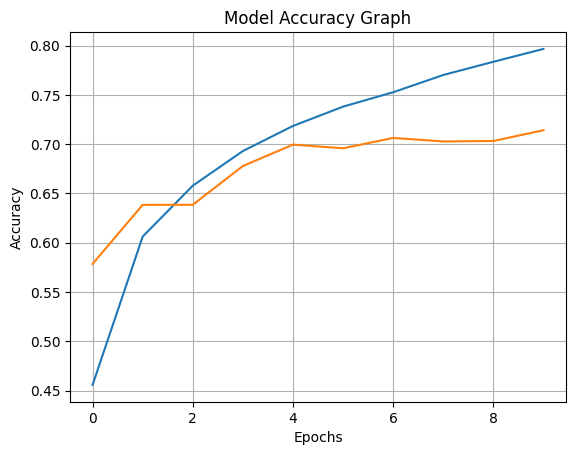

In [59]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy Graph')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.grid(True)
plt.show()

In [60]:
def load_and_prepare_image(img):
  image = Image.open(img).convert('RGB')
  image = image.resize((32, 32))
  image_array = np.array(image) / 255.0
  image_array = np.expand_dims(image_array, 0)

  return image_array

In [65]:
custom_image_path = "b5.jpg" #@param {type:"string"}

In [62]:
import os

In [69]:
if os.path.exists(custom_image_path):
  try:
    prepared_image = load_and_prepare_image(custom_image_path)
    prediction = model.predict(prepared_image)
    print(prediction)
    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction)

    print(f"Predicted class: {class_name[predicted_class]}\nConfidence: {confidence}")
  except Exception as e:
    print(f"Error occured: {e}")
else:
  print(f"Image {custom_image_path} doesn't exist")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[[2.5110891e-02 2.3293015e-04 4.4286010e-01 7.9444367e-03 4.7153431e-01
  3.1482827e-02 1.7484110e-02 2.6379309e-03 4.5362947e-04 2.5891140e-04]]
Predicted class: deer
Confidence: 0.4715343117713928


class_name = ['airplane', 'car', 'bird', 'cat', 'deer', 'dog', 'toad', 'horse', 'ship', 'truck']

Upload a .jpg or .png file:


Saving 2.jpg to 2.jpg
Saving dg2.jpg to dg2.jpg
Saving s4.jpg to s4.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted class: car
Confidence: 0.9999967813491821


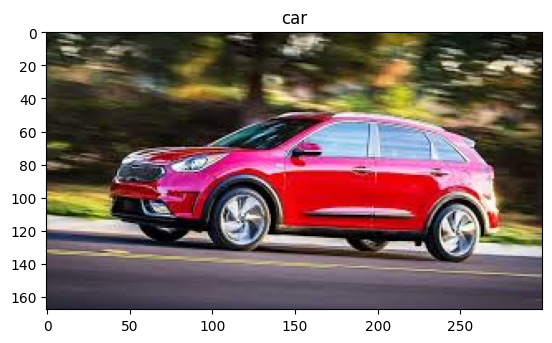

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted class: deer
Confidence: 0.4622555673122406


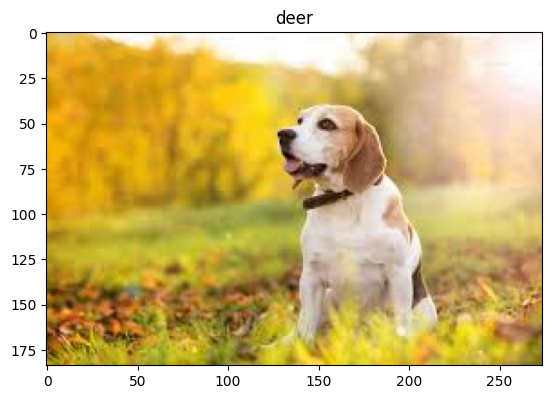

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted class: ship
Confidence: 0.7347150444984436


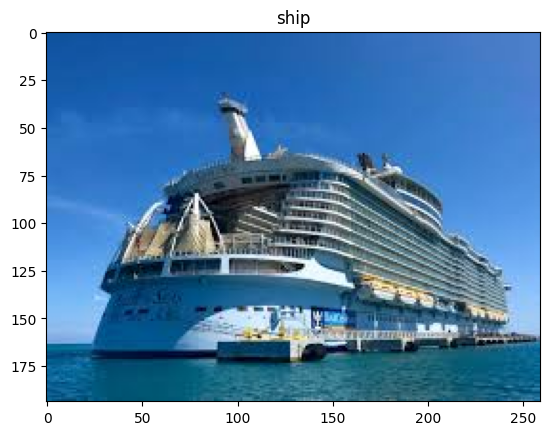

In [84]:
from google.colab import files

print("Upload a .jpg or .png file:")
uploaded = files.upload()

for f in uploaded.keys():
  if os.path.exists(f):
    try:
      prepared_image = load_and_prepare_image(f)
      prediction = model.predict(prepared_image)
      # print(prediction)
      predicted_class = np.argmax(prediction)
      confidence = np.max(prediction)

      print(f"Predicted class: {class_name[predicted_class]}\nConfidence: {confidence}")

      img = Image.open(f)
      # display(img)
      plt.imshow(img)
      plt.title(class_name[predicted_class])
      plt.show()
    except Exception as e:
      print(f"Error occured: {e}")
  else:
    print(f"Image {f} doesn't exist")